In [ ]:
!pip -q install openpyxl

import pandas as pd
from pathlib import Path

In [ ]:
DATA_DIR = Path("/content")

PEMS_FILES = {
    "high":  DATA_DIR / "merged_data_high_congestion.xlsx",
    "low":   DATA_DIR / "merged_data_low_congestion.xlsx",
    "rural": DATA_DIR / "merged_data_rural.xlsx",
    "urban": DATA_DIR / "merged_data_urban.xlsx",
}

SL_FILES = {
    "high":  DATA_DIR / "high_congestion.csv",
    "low":   DATA_DIR / "low_congestion.csv",
    "rural": DATA_DIR / "rural_region.csv",
    "urban": DATA_DIR / "urban_region.csv",
}

pems_raw = {}
sl_raw = {}


for k, fp in PEMS_FILES.items():
    print("\n" + "="*110)
    print(f"PeMS | {k} | file={fp.name}")


    xls = pd.ExcelFile(fp)
    print("Sheets:", xls.sheet_names)


    df = pd.read_excel(fp, sheet_name=xls.sheet_names[0], engine="openpyxl")
    pems_raw[k] = df

    print("Shape:", df.shape)
    print("Columns:", list(df.columns))
    print(df.head(5))


for k, fp in SL_FILES.items():
    print("\n" + "="*110)
    print(f"StreetLight | {k} | file={fp.name}")

    df = pd.read_csv(fp)
    sl_raw[k] = df

    print("Shape:", df.shape)
    print("Columns:", list(df.columns))
    print(df.head(5))


PeMS | high | file=merged_data_high_congestion.xlsx
Sheets: ['Sheet1']
Shape: (744, 23)
Columns: ['Hour', 'Flow_df1', 'Speed_df1', 'Flow_df2', 'Speed_df2', 'Flow_df3', 'Speed_df3', 'Flow_df4', 'Speed_df4', 'Flow_df5', 'Speed_df5', 'Flow_df6', 'Speed_df6', 'Flow_df7', 'Speed_df7', 'Flow_df8', 'Speed_df8', 'Flow_df9', 'Speed_df9', 'Flow_df10', 'Speed_df10', 'Flow_df11', 'Speed_df11']
                 Hour  Flow_df1  Speed_df1  Flow_df2  Speed_df2  Flow_df3  \
0 2025-01-01 00:00:00       169       65.1       169       65.1       169   
1 2025-01-01 01:00:00        83       64.9        83       64.9        83   
2 2025-01-01 02:00:00        60       65.5        60       65.5        60   
3 2025-01-01 03:00:00       100       65.1       100       65.1       100   
4 2025-01-01 04:00:00       382       65.2       382       65.2       382   

   Speed_df3  Flow_df4  Speed_df4  Flow_df5  ...  Flow_df7  Speed_df7  \
0       65.1      1867       69.7      1471  ...      1474       68.8   
1    

In [ ]:
def quick_check(name, df):
    print("\n" + "-"*110)
    print(name)
    print("Dtypes:")
    print(df.dtypes)

    miss = df.isna().mean().sort_values(ascending=False)
    miss = miss[miss > 0]
    print("\nMissingness (>0):")
    print(miss.head(15) if len(miss) else "No missing values detected.")


    for col in df.columns:
        cl = col.lower()
        if any(x in cl for x in ["timestamp", "time", "date", "datetime", "hour"]):
            print(f"\nSample timestamp-like values from '{col}':")
            print(df[col].astype(str).head(8).tolist())
        if any(x in cl for x in ["station", "detector", "site", "sensor", "id"]):
            print(f"\nSample station/id-like values from '{col}':")
            print(df[col].astype(str).head(8).tolist())

for k, df in pems_raw.items():
    quick_check(f"PeMS/{k}", df)

for k, df in sl_raw.items():
    quick_check(f"StreetLight/{k}", df)


--------------------------------------------------------------------------------------------------------------
PeMS/high
Dtypes:
Hour          datetime64[ns]
Flow_df1               int64
Speed_df1            float64
Flow_df2               int64
Speed_df2            float64
Flow_df3               int64
Speed_df3            float64
Flow_df4               int64
Speed_df4            float64
Flow_df5               int64
Speed_df5            float64
Flow_df6               int64
Speed_df6            float64
Flow_df7               int64
Speed_df7            float64
Flow_df8               int64
Speed_df8            float64
Flow_df9               int64
Speed_df9            float64
Flow_df10              int64
Speed_df10           float64
Flow_df11              int64
Speed_df11           float64
dtype: object

Missingness (>0):
No missing values detected.

Sample timestamp-like values from 'Hour':
['2025-01-01 00:00:00', '2025-01-01 01:00:00', '2025-01-01 02:00:00', '2025-01-01 03:00:00', '2025-

In [ ]:
import pandas as pd
import numpy as np

def inspect_streetlight(df, name):
    print("\n" + "="*110)
    print("StreetLight:", name)
    print("shape:", df.shape)
    print("unique zones:", df["Zone Name"].nunique())
    print("zone min/max:", df["Zone Name"].min(), df["Zone Name"].max())

    # unique days
    print("unique Day Type:", df["Day Type"].nunique())
    print("Day Type range:", df["Day Type"].min(), "→", df["Day Type"].max())

    # unique day parts (hours)
    print("unique Day Part:", df["Day Part"].nunique())
    print("first 10 Day Part:", df["Day Part"].dropna().unique()[:10])


    # rows ≈ zones * 31 days * 24 hours
    z = df["Zone Name"].nunique()
    expected = z * 31 * 24
    print("expected rows (zones*31*24):", expected)
    print("actual rows:", len(df), "| ratio actual/expected:", round(len(df)/expected, 4))


inspect_streetlight(sl_raw["high"], "high")
inspect_streetlight(sl_raw["low"], "low")
inspect_streetlight(sl_raw["rural"], "rural")
inspect_streetlight(sl_raw["urban"], "urban")


StreetLight: high
shape: (10304, 7)
unique zones: 14
zone min/max: 1 14
unique Day Type: 31
Day Type range: 01/01/2025 → 01/31/2025
unique Day Part: 24
first 10 Day Part: ['01: 12am (12am-1am)' '02: 1am (1am-2am)' '03: 2am (2am-3am)'
 '04: 3am (3am-4am)' '05: 4am (4am-5am)' '06: 5am (5am-6am)'
 '07: 6am (6am-7am)' '08: 7am (7am-8am)' '09: 8am (8am-9am)'
 '10: 9am (9am-10am)']
expected rows (zones*31*24): 10416
actual rows: 10304 | ratio actual/expected: 0.9892

StreetLight: low
shape: (8832, 7)
unique zones: 12
zone min/max: 1 12
unique Day Type: 31
Day Type range: 01/01/2025 → 01/31/2025
unique Day Part: 24
first 10 Day Part: ['01: 12am (12am-1am)' '02: 1am (1am-2am)' '03: 2am (2am-3am)'
 '04: 3am (3am-4am)' '05: 4am (4am-5am)' '06: 5am (5am-6am)'
 '07: 6am (6am-7am)' '08: 7am (7am-8am)' '09: 8am (8am-9am)'
 '10: 9am (9am-10am)']
expected rows (zones*31*24): 8928
actual rows: 8832 | ratio actual/expected: 0.9892

StreetLight: rural
shape: (8832, 7)
unique zones: 12
zone min/max: 1 12

In [ ]:
import re

def inspect_pems(df, name):
    print("\n" + "="*110)
    print("PeMS:", name)
    print("shape:", df.shape)


    flow_cols = [c for c in df.columns if c.startswith("Flow_df")]
    speed_cols = [c for c in df.columns if c.startswith("Speed_df")]
    get_num = lambda c: int(re.findall(r"df(\d+)", c)[0])

    flow_ids = sorted(get_num(c) for c in flow_cols)
    speed_ids = sorted(get_num(c) for c in speed_cols)
    print("num detectors (flow):", len(flow_ids), "| ids:", flow_ids)
    print("num detectors (speed):", len(speed_ids), "| ids:", speed_ids)


inspect_pems(pems_raw["high"], "high")
inspect_pems(pems_raw["low"], "low")
inspect_pems(pems_raw["rural"], "rural")
inspect_pems(pems_raw["urban"], "urban")


PeMS: high
shape: (744, 23)
num detectors (flow): 11 | ids: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
num detectors (speed): 11 | ids: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]

PeMS: low
shape: (744, 19)
num detectors (flow): 9 | ids: [1, 2, 3, 4, 5, 6, 7, 8, 9]
num detectors (speed): 9 | ids: [1, 2, 3, 4, 5, 6, 7, 8, 9]

PeMS: rural
shape: (744, 21)
num detectors (flow): 10 | ids: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
num detectors (speed): 10 | ids: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

PeMS: urban
shape: (744, 23)
num detectors (flow): 11 | ids: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
num detectors (speed): 11 | ids: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]


In [ ]:
import re
import pandas as pd
import numpy as np

def pems_wide_to_long(df, region):
    out = df.copy()
    out = out.rename(columns={"Hour": "timestamp"})
    flow_cols  = [c for c in out.columns if c.startswith("Flow_df")]
    speed_cols = [c for c in out.columns if c.startswith("Speed_df")]

    # melt flow
    f = out[["timestamp"] + flow_cols].melt("timestamp", var_name="det_col", value_name="flow")
    f["id"] = f["det_col"].str.extract(r"df(\d+)").astype(int)

    # melt speed
    s = out[["timestamp"] + speed_cols].melt("timestamp", var_name="det_col", value_name="speed")
    s["id"] = s["det_col"].str.extract(r"df(\d+)").astype(int)

    long = f.drop(columns=["det_col"]).merge(s.drop(columns=["det_col"]), on=["timestamp","id"], how="inner")
    long["region"] = region
    long["source"] = "pems"
    return long

pems_long = pd.concat([
    pems_wide_to_long(pems_raw["high"], "high"),
    pems_wide_to_long(pems_raw["low"], "low"),
    pems_wide_to_long(pems_raw["rural"], "rural"),
    pems_wide_to_long(pems_raw["urban"], "urban"),
], ignore_index=True)

print("PeMS long:", pems_long.shape)
pems_long.head()

PeMS long: (30504, 6)


,timestamp,flow,id,speed,region,source
0,2025-01-01 00:00:00,169.0,1,65.1,high,pems
1,2025-01-01 01:00:00,83.0,1,64.9,high,pems
2,2025-01-01 02:00:00,60.0,1,65.5,high,pems
3,2025-01-01 03:00:00,100.0,1,65.1,high,pems
4,2025-01-01 04:00:00,382.0,1,65.2,high,pems


In [ ]:
def streetlight_to_long(df, region):
    out = df.copy()

    out["date"] = pd.to_datetime(out["Day Type"], format="%m/%d/%Y", errors="coerce")
    # hour index: "01: 12am ..." -> 0, "02: 1am ..." -> 1, ..., "24: 11pm ..." -> 23
    out["hour_idx"] = out["Day Part"].str.extract(r"^(\d+):").astype(float) - 1
    out["timestamp"] = out["date"] + pd.to_timedelta(out["hour_idx"], unit="h")

    long = pd.DataFrame({
        "timestamp": out["timestamp"],
        "id": out["Zone Name"].astype(int),
        "flow": out["Average Daily Spot Traffic (StL Volume)"].astype(float),
        "speed": out["Avg Spot Speed (mph)"].astype(float),
        "region": region,
        "source": "streetlight",
    })
    return long

sl_long = pd.concat([
    streetlight_to_long(sl_raw["high"], "high"),
    streetlight_to_long(sl_raw["low"], "low"),
    streetlight_to_long(sl_raw["rural"], "rural"),
    streetlight_to_long(sl_raw["urban"], "urban"),
], ignore_index=True)

print("StreetLight long:", sl_long.shape)
sl_long.head()

StreetLight long: (58880, 6)


,timestamp,id,flow,speed,region,source
0,2025-01-01 00:00:00,1,3699.0,65.0,high,streetlight
1,2025-01-01 01:00:00,1,4777.0,62.0,high,streetlight
2,2025-01-01 02:00:00,1,4908.0,65.0,high,streetlight
3,2025-01-01 03:00:00,1,3317.0,67.0,high,streetlight
4,2025-01-01 04:00:00,1,1929.0,67.0,high,streetlight


In [ ]:
def time_coverage_check(long_df, name):
    print("\n" + "="*110)
    print(name)
    for region, g in long_df.groupby("region"):
        ts = g["timestamp"].dropna()
        print(region,
              "| min:", ts.min(),
              "| max:", ts.max(),
              "| unique timestamps:", ts.nunique(),
              "| rows:", len(g),
              "| unique ids:", g["id"].nunique())

time_coverage_check(pems_long, "PeMS long")
time_coverage_check(sl_long, "StreetLight long")


PeMS long
high | min: 2025-01-01 00:00:00 | max: 2025-01-31 23:00:00 | unique timestamps: 744 | rows: 8184 | unique ids: 11
low | min: 2025-01-01 00:00:00 | max: 2025-01-31 23:00:00 | unique timestamps: 744 | rows: 6696 | unique ids: 9
rural | min: 2025-01-01 00:00:00 | max: 2025-01-31 23:00:00 | unique timestamps: 744 | rows: 7440 | unique ids: 10
urban | min: 2025-01-01 00:00:00 | max: 2025-01-31 23:00:00 | unique timestamps: 744 | rows: 8184 | unique ids: 11

StreetLight long
high | min: 2025-01-01 00:00:00 | max: 2025-01-31 15:00:00 | unique timestamps: 736 | rows: 10304 | unique ids: 14
low | min: 2025-01-01 00:00:00 | max: 2025-01-31 15:00:00 | unique timestamps: 736 | rows: 8832 | unique ids: 12
rural | min: 2025-01-01 00:00:00 | max: 2025-01-31 15:00:00 | unique timestamps: 736 | rows: 8832 | unique ids: 12
urban | min: 2025-01-01 00:00:00 | max: 2025-01-31 15:00:00 | unique timestamps: 736 | rows: 30912 | unique ids: 42


In [ ]:
# Align timestamps (truncate PeMS to StreetLight coverage)
import pandas as pd

def align_time_window(pems_long: pd.DataFrame, sl_long: pd.DataFrame):
    # Global overlap window (simple + safe)
    p_min, p_max = pems_long["timestamp"].min(), pems_long["timestamp"].max()
    s_min, s_max = sl_long["timestamp"].min(), sl_long["timestamp"].max()

    t_start = max(p_min, s_min)
    t_end   = min(p_max, s_max)

    print("PeMS window:      ", p_min, "→", p_max)
    print("StreetLight window:", s_min, "→", s_max)
    print("Overlap window:   ", t_start, "→", t_end)

    p_aligned = pems_long[(pems_long["timestamp"] >= t_start) & (pems_long["timestamp"] <= t_end)].copy()
    s_aligned = sl_long[(sl_long["timestamp"] >= t_start) & (sl_long["timestamp"] <= t_end)].copy()

    return p_aligned, s_aligned, t_start, t_end

pems_aligned, sl_aligned, t_start, t_end = align_time_window(pems_long, sl_long)


def coverage_check(df, name):
    print("\n" + "="*110)
    print(name)
    for r in ["high", "low", "rural", "urban"]:
        dfr = df[df["region"] == r]
        if len(dfr) == 0:
            print(r, "| EMPTY")
            continue
        print(
            f"{r:5s} | min: {dfr['timestamp'].min()} | max: {dfr['timestamp'].max()} "
            f"| unique timestamps: {dfr['timestamp'].nunique()} | rows: {len(dfr)} | unique ids: {dfr['id'].nunique()}"
        )

coverage_check(pems_aligned, "PeMS aligned")
coverage_check(sl_aligned, "StreetLight aligned")


def check_timestamp_sets_match(p_df, s_df):
    print("\n" + "="*110)
    print("Timestamp set match check (per region)")
    for r in ["high", "low", "rural", "urban"]:
        pt = set(p_df.loc[p_df["region"] == r, "timestamp"].unique())
        st = set(s_df.loc[s_df["region"] == r, "timestamp"].unique())
        inter = len(pt & st)
        only_p = len(pt - st)
        only_s = len(st - pt)
        print(f"{r:5s} | pems={len(pt)} sl={len(st)} | intersect={inter} | only_pems={only_p} | only_sl={only_s}")

check_timestamp_sets_match(pems_aligned, sl_aligned)

PeMS window:       2025-01-01 00:00:00 → 2025-01-31 23:00:00
StreetLight window: 2025-01-01 00:00:00 → 2025-01-31 15:00:00
Overlap window:    2025-01-01 00:00:00 → 2025-01-31 15:00:00

PeMS aligned
high  | min: 2025-01-01 00:00:00 | max: 2025-01-31 15:00:00 | unique timestamps: 736 | rows: 8096 | unique ids: 11
low   | min: 2025-01-01 00:00:00 | max: 2025-01-31 15:00:00 | unique timestamps: 736 | rows: 6624 | unique ids: 9
rural | min: 2025-01-01 00:00:00 | max: 2025-01-31 15:00:00 | unique timestamps: 736 | rows: 7360 | unique ids: 10
urban | min: 2025-01-01 00:00:00 | max: 2025-01-31 15:00:00 | unique timestamps: 736 | rows: 8096 | unique ids: 11

StreetLight aligned
high  | min: 2025-01-01 00:00:00 | max: 2025-01-31 15:00:00 | unique timestamps: 736 | rows: 10304 | unique ids: 14
low   | min: 2025-01-01 00:00:00 | max: 2025-01-31 15:00:00 | unique timestamps: 736 | rows: 8832 | unique ids: 12
rural | min: 2025-01-01 00:00:00 | max: 2025-01-31 15:00:00 | unique timestamps: 736 | rows

In [ ]:
# Shared feature space (Option A: derived features)

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

def add_time_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["hour"] = out["timestamp"].dt.hour
    out["dow"]  = out["timestamp"].dt.dayofweek
    out["hour_sin"] = np.sin(2*np.pi*out["hour"]/24)
    out["hour_cos"] = np.cos(2*np.pi*out["hour"]/24)
    out["dow_sin"]  = np.sin(2*np.pi*out["dow"]/7)
    out["dow_cos"]  = np.cos(2*np.pi*out["dow"]/7)
    return out

def add_density_proxy(df: pd.DataFrame, eps=1e-6) -> pd.DataFrame:
    out = df.copy()
    out["density_proxy"] = out["flow"] / out["speed"].clip(lower=eps)
    return out

def add_station_dynamics(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out = out.sort_values(["region", "id", "timestamp"])
    g = out.groupby(["region", "id"], sort=False)
    out["flow_diff1"]  = g["flow"].diff().fillna(0.0)
    out["speed_diff1"] = g["speed"].diff().fillna(0.0)
    return out

# 1) Feature engineering (done identically for both sources)
p_feat = add_station_dynamics(add_density_proxy(add_time_features(pems_aligned)))
s_feat = add_station_dynamics(add_density_proxy(add_time_features(sl_aligned)))

# 2) Define the shared feature columns
FEAT_COLS = [
    "flow",
    "speed",
    "density_proxy",
    "flow_diff1",
    "speed_diff1",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
]

# 3) Build per-region feature matrices, with shared scaling per region
def build_region_feature_mats(p_df: pd.DataFrame, s_df: pd.DataFrame, feat_cols):
    region_mats = {}
    for r in ["high", "low", "rural", "urban"]:
        P = p_df[p_df["region"] == r].copy()
        S = s_df[s_df["region"] == r].copy()

        # Keep only rows with all feature cols present
        P = P.dropna(subset=feat_cols)
        S = S.dropna(subset=feat_cols)

        X = P[feat_cols].to_numpy(float)
        Y = S[feat_cols].to_numpy(float)

        # Shared scaling (fit scaler on pooled samples for that region)
        scaler = StandardScaler()
        Z = scaler.fit_transform(np.vstack([X, Y]))
        Xs = Z[:len(X)]
        Ys = Z[len(X):]

        region_mats[r] = {
            "X_raw": X,
            "Y_raw": Y,
            "X": Xs,
            "Y": Ys,
            "scaler": scaler,
            "n_pems": len(X),
            "n_sl": len(Y),
        }
    return region_mats

region_mats_A = build_region_feature_mats(p_feat, s_feat, FEAT_COLS)


print("Step 4A: Feature matrices ready (scaled).")
for r, obj in region_mats_A.items():
    print(
        f"{r:5s} | X(PeMS)={obj['n_pems']:6d}  Y(StreetLight)={obj['n_sl']:6d}  "
        f"dim={obj['X'].shape[1]}"
    )


r0 = "high"
print("\nExample (first 3 scaled rows) region =", r0)
print("PeMS X[:3]:\n", region_mats_A[r0]["X"][:3])
print("StreetLight Y[:3]:\n", region_mats_A[r0]["Y"][:3])

Step 4A: Feature matrices ready (scaled).
high  | X(PeMS)=  8096  Y(StreetLight)= 10304  dim=9
low   | X(PeMS)=  6624  Y(StreetLight)=  8832  dim=9
rural | X(PeMS)=  7360  Y(StreetLight)=  8832  dim=9
urban | X(PeMS)=  8096  Y(StreetLight)= 30910  dim=9

Example (first 3 scaled rows) region = high
PeMS X[:3]:
 [[-1.50704331  0.38991994 -1.21962028 -0.00567465  0.00327401 -0.01179818
   1.41683364  1.33191169 -0.23539629]
 [-1.54203687  0.36798995 -1.24357075 -0.11999696 -0.0345426   0.3548425
   1.36872218  1.33191169 -0.23539629]
 [-1.55139562  0.43377991 -1.250169   -0.03624922  0.11672385  0.69649721
   1.22766651  1.33191169 -0.23539629]]
StreetLight Y[:3]:
 [[-0.07067944  0.37895495 -0.232015   -0.00567465  0.00327401 -0.01179818
   1.41683364  1.33191169 -0.23539629]
 [ 0.36796085  0.05000514  0.13422398  1.42734225 -0.56397515  0.3548425
   1.36872218  1.33191169 -0.23539629]
 [ 0.42126501  0.37895495  0.10620794  0.16846748  0.57052318  0.69649721
   1.22766651  1.33191169 -0.2

In [ ]:
# Shared latent space


import numpy as np
from sklearn.decomposition import PCA

def build_region_pca_latent(region_mats_A, n_components=3, seed=0):
    region_mats_B = {}

    for r, obj in region_mats_A.items():
        X = obj["X"]   # scaled PeMS
        Y = obj["Y"]   # scaled StreetLight

        # Fit PCA on pooled samples so the latent space is shared
        Z = np.vstack([X, Y])

        pca = PCA(n_components=n_components, random_state=seed)
        Z_lat = pca.fit_transform(Z)

        X_lat = Z_lat[:len(X)]
        Y_lat = Z_lat[len(X):]

        region_mats_B[r] = {
            "X_latent": X_lat,
            "Y_latent": Y_lat,
            "pca": pca,
            "explained_var_ratio": pca.explained_variance_ratio_,
            "n_components": n_components,
            "n_pems": len(X),
            "n_sl": len(Y),
        }

    return region_mats_B

# Choose latent dim
region_mats_B = build_region_pca_latent(region_mats_A, n_components=3, seed=0)

print("Step 4B: PCA latent matrices ready.")
for r, obj in region_mats_B.items():
    ev = obj["explained_var_ratio"]
    print(
        f"{r:5s} | X_lat={obj['X_latent'].shape}  Y_lat={obj['Y_latent'].shape} | "
        f"EVR={np.round(ev, 4)}  sum={ev.sum():.4f}"
    )


r0 = "high"
print("\nExample latent (first 3 rows) region =", r0)
print("PeMS X_latent[:3]:\n", region_mats_B[r0]["X_latent"][:3])
print("StreetLight Y_latent[:3]:\n", region_mats_B[r0]["Y_latent"][:3])

Step 4B: PCA latent matrices ready.
high  | X_lat=(8096, 3)  Y_lat=(10304, 3) | EVR=[0.3439 0.1827 0.1143]  sum=0.6409
low   | X_lat=(6624, 3)  Y_lat=(8832, 3) | EVR=[0.3225 0.1798 0.1416]  sum=0.6438
rural | X_lat=(7360, 3)  Y_lat=(8832, 3) | EVR=[0.3397 0.183  0.1217]  sum=0.6444
urban | X_lat=(8096, 3)  Y_lat=(30910, 3) | EVR=[0.3304 0.1781 0.1246]  sum=0.6330

Example latent (first 3 rows) region = high
PeMS X_latent[:3]:
 [[-2.09557578  0.01390148  1.61330449]
 [-2.14813418  0.20652538  1.64458882]
 [-2.18083673  0.44698298  1.58432799]]
StreetLight Y_latent[:3]:
 [[-0.82932031 -0.22297159  1.45100656]
 [-0.01403794  1.04319291  1.4310569 ]
 [-0.46257981  0.07354935  1.2652984 ]]


### Mathematical Definition — Energy Distance

Let

$$
X = \{x_1, x_2, ..., x_n\}
$$

be the PeMS observations and

$$
Y = \{y_1, y_2, ..., y_m\}
$$

be the StreetLight observations.

Each observation is represented as a vector in the shared PCA latent space.

---

The **Energy Distance** between the two distributions \(X\) and \(Y\) is defined as

$$
D_E(X,Y) = 2E\|X - Y\| - E\|X - X'\| - E\|Y - Y'\|
$$

where

- \(E\|X - Y\|\) is the expected distance between a PeMS observation and a StreetLight observation  
- \(E\|X - X'\|\) is the expected distance between two PeMS observations  
- \(E\|Y - Y'\|\) is the expected distance between two StreetLight observations

In [ ]:
# Energy Distance

import numpy as np
from scipy.spatial.distance import cdist

def energy_distance(X, Y):
    XY = cdist(X, Y)
    XX = cdist(X, X)
    YY = cdist(Y, Y)

    return 2*np.mean(XY) - np.mean(XX) - np.mean(YY)

energy_results = {}

for r, obj in region_mats_B.items():
    X = obj["X_latent"]
    Y = obj["Y_latent"]

    d = energy_distance(X, Y)
    energy_results[r] = d

print("Energy Distance Results")
for r, v in energy_results.items():
    print(r, ":", round(v,6))

Energy Distance Results
high : 0.099752
low : 0.192366
rural : 0.185375
urban : 0.031564


### Mathematical Definition — Sliced Wasserstein Distance

Let

$$
X = \{x_1, x_2, ..., x_n\}
$$

be the PeMS observations and

$$
Y = \{y_1, y_2, ..., y_m\}
$$

be the StreetLight observations, where each observation lies in a \(d\)-dimensional space.

Let

$$
\theta \in S^{d-1}
$$

be a random unit vector drawn from the unit sphere.

The projection of a point \(x\) onto the direction $\theta$ is

$$
x_\theta = x \cdot \theta
$$

---

The **Sliced Wasserstein Distance** between the two distributions is defined as

$$
SW(X,Y) =
\mathbb{E}_{\theta \sim S^{d-1}}
\left[
W(X_\theta, Y_\theta)
\right]
$$

where $W(\cdot,\cdot)$ denotes the **1-dimensional Wasserstein distance** between the projected distributions.

---

In practice, the expectation is approximated using \(K\) random projections:

$$
SW(X,Y) \approx
\frac{1}{K}
\sum_{k=1}^{K}
W(X_{\theta_k}, Y_{\theta_k})
$$

In [ ]:
# Sliced Wasserstein Distance

import numpy as np
from scipy.stats import wasserstein_distance

def sliced_wasserstein(X, Y, n_proj=100, seed=0):
    rng = np.random.default_rng(seed)
    d = X.shape[1]

    distances = []

    for _ in range(n_proj):
        theta = rng.normal(size=d)
        theta /= np.linalg.norm(theta)

        Xp = X @ theta
        Yp = Y @ theta

        distances.append(wasserstein_distance(Xp, Yp))

    return np.mean(distances)

sw_results = {}

for r, obj in region_mats_B.items():
    X = obj["X_latent"]
    Y = obj["Y_latent"]

    d = sliced_wasserstein(X, Y, n_proj=100)
    sw_results[r] = d

print("Sliced Wasserstein Results")
for r, v in sw_results.items():
    print(r, ":", round(v,6))

Sliced Wasserstein Results
high : 0.316839
low : 0.377028
rural : 0.35981
urban : 0.173426


### Mathematical Definition — Maximum Mean Discrepancy (MMD)

Let

$$
X = \{x_1, x_2, ..., x_n\}
$$

be the PeMS observations and

$$
Y = \{y_1, y_2, ..., y_m\}
$$

be the StreetLight observations.

Each observation lies in a feature space, and a kernel function \(k(x,y)\) is used to measure similarity between points.

---

The **Maximum Mean Discrepancy (MMD)** between the two distributions is defined as

$$
\mathrm{MMD}^2(X,Y)
=
\mathrm{E}[k(X,X')] +
\mathrm{E}[k(Y,Y')] -
2\mathrm{E}[k(X,Y)]
$$

where

- $k(\cdot,\cdot)$ is a positive definite kernel function  
- \(X, X'\) are two independent samples drawn from distribution \(X\)  
- \(Y, Y'\) are two independent samples drawn from distribution \(Y\)

---

In practice, the empirical estimator of MMD is

$$
\mathrm{MMD}^2(X,Y)
=
\frac{1}{n^2}\sum_{i=1}^{n}\sum_{j=1}^{n} k(x_i,x_j)
+
\frac{1}{m^2}\sum_{i=1}^{m}\sum_{j=1}^{m} k(y_i,y_j)
-
\frac{2}{nm}\sum_{i=1}^{n}\sum_{j=1}^{m} k(x_i,y_j)
$$

---

In this work, the **Gaussian Radial Basis Function (RBF) kernel** is used:

$$
k(x,y) = \exp(-\gamma \|x-y\|^2)
$$

In [ ]:
# Maximum Mean Discrepancy (Gaussian kernel)

import numpy as np
from sklearn.metrics.pairwise import rbf_kernel

def compute_mmd(X, Y, gamma=None):
    if gamma is None:
        gamma = 1 / X.shape[1]  # simple heuristic

    Kxx = rbf_kernel(X, X, gamma)
    Kyy = rbf_kernel(Y, Y, gamma)
    Kxy = rbf_kernel(X, Y, gamma)

    return Kxx.mean() + Kyy.mean() - 2*Kxy.mean()

mmd_results = {}

for r, obj in region_mats_B.items():
    X = obj["X_latent"]
    Y = obj["Y_latent"]

    d = compute_mmd(X, Y)
    mmd_results[r] = d

print("MMD Results")
for r, v in mmd_results.items():
    print(r, ":", round(v,6))

MMD Results
high : 0.017473
low : 0.045333
rural : 0.042902
urban : 0.007469


          energy  wasserstein       mmd
region                                 
high    0.099752     0.316839  0.017473
low     0.192366     0.377028  0.045333
rural   0.185375     0.359810  0.042902
urban   0.031564     0.173426  0.007469


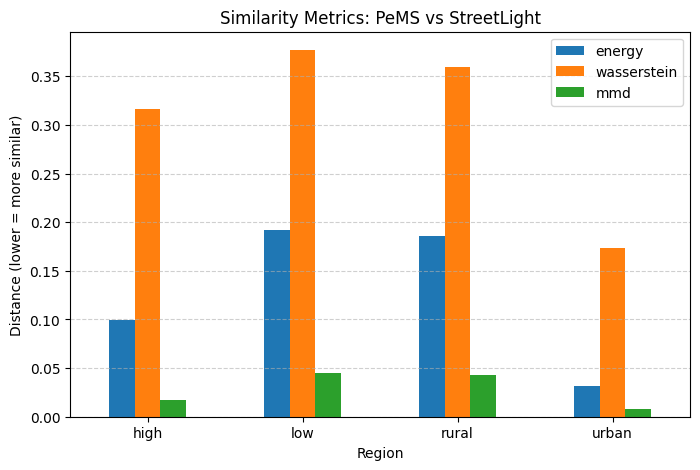

In [ ]:
# Bar chart comparison of similarity metrics

import pandas as pd
import matplotlib.pyplot as plt

# Combine results into a dataframe
results_df = pd.DataFrame({
    "region": ["high", "low", "rural", "urban"],
    "energy": [energy_results[r] for r in ["high","low","rural","urban"]],
    "wasserstein": [sw_results[r] for r in ["high","low","rural","urban"]],
    "mmd": [mmd_results[r] for r in ["high","low","rural","urban"]],
})

results_df = results_df.set_index("region")

print(results_df)

# Plot
results_df.plot(kind="bar", figsize=(8,5))

plt.title("Similarity Metrics: PeMS vs StreetLight")
plt.ylabel("Distance (lower = more similar)")
plt.xlabel("Region")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()

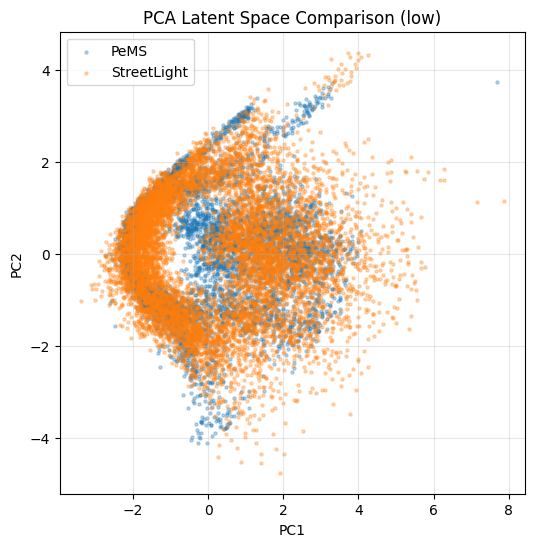

In [ ]:
# PCA scatter plot (PeMS vs StreetLight)

import matplotlib.pyplot as plt

region = "low"

X = region_mats_B[region]["X_latent"]
Y = region_mats_B[region]["Y_latent"]

plt.figure(figsize=(6,6))

plt.scatter(X[:,0], X[:,1], s=5, alpha=0.3, label="PeMS")
plt.scatter(Y[:,0], Y[:,1], s=5, alpha=0.3, label="StreetLight")

plt.title(f"PCA Latent Space Comparison ({region})")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

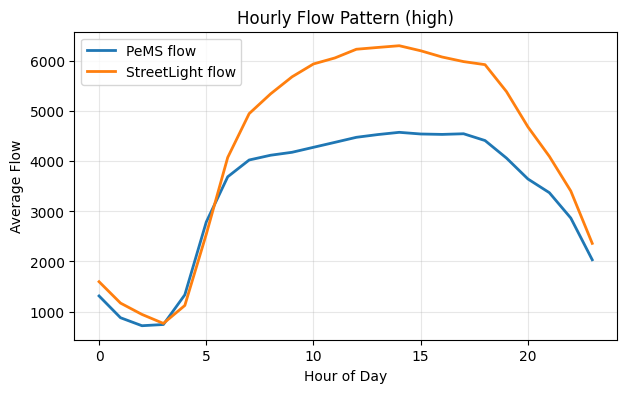

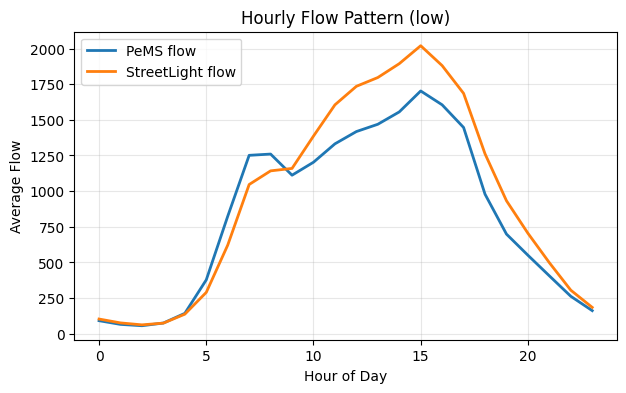

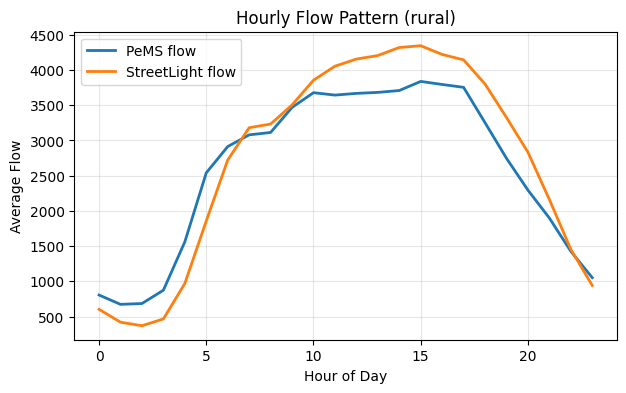

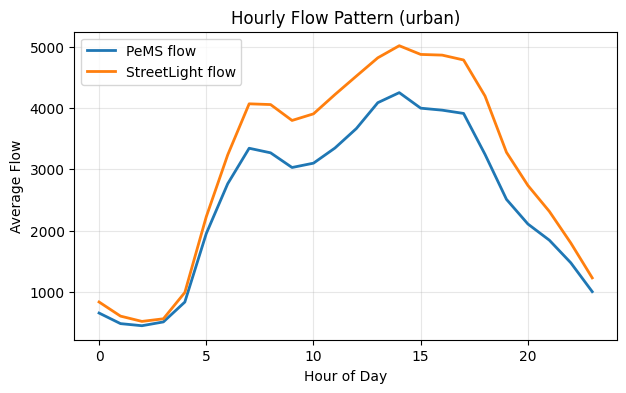

In [ ]:
# Hour-of-day traffic comparison

import pandas as pd
import matplotlib.pyplot as plt

def hourly_profile(df):
    df = df.copy()
    df["hour"] = df["timestamp"].dt.hour

    return df.groupby(["region","hour"])[["flow","speed"]].mean().reset_index()

pems_hourly = hourly_profile(pems_aligned)
sl_hourly = hourly_profile(sl_aligned)

regions = ["high","low","rural","urban"]

for r in regions:

    p = pems_hourly[pems_hourly.region == r]
    s = sl_hourly[sl_hourly.region == r]

    plt.figure(figsize=(7,4))

    plt.plot(p["hour"], p["flow"], label="PeMS flow", linewidth=2)
    plt.plot(s["hour"], s["flow"], label="StreetLight flow", linewidth=2)

    plt.title(f"Hourly Flow Pattern ({r})")
    plt.xlabel("Hour of Day")
    plt.ylabel("Average Flow")

    plt.grid(alpha=0.3)
    plt.legend()

    plt.show()

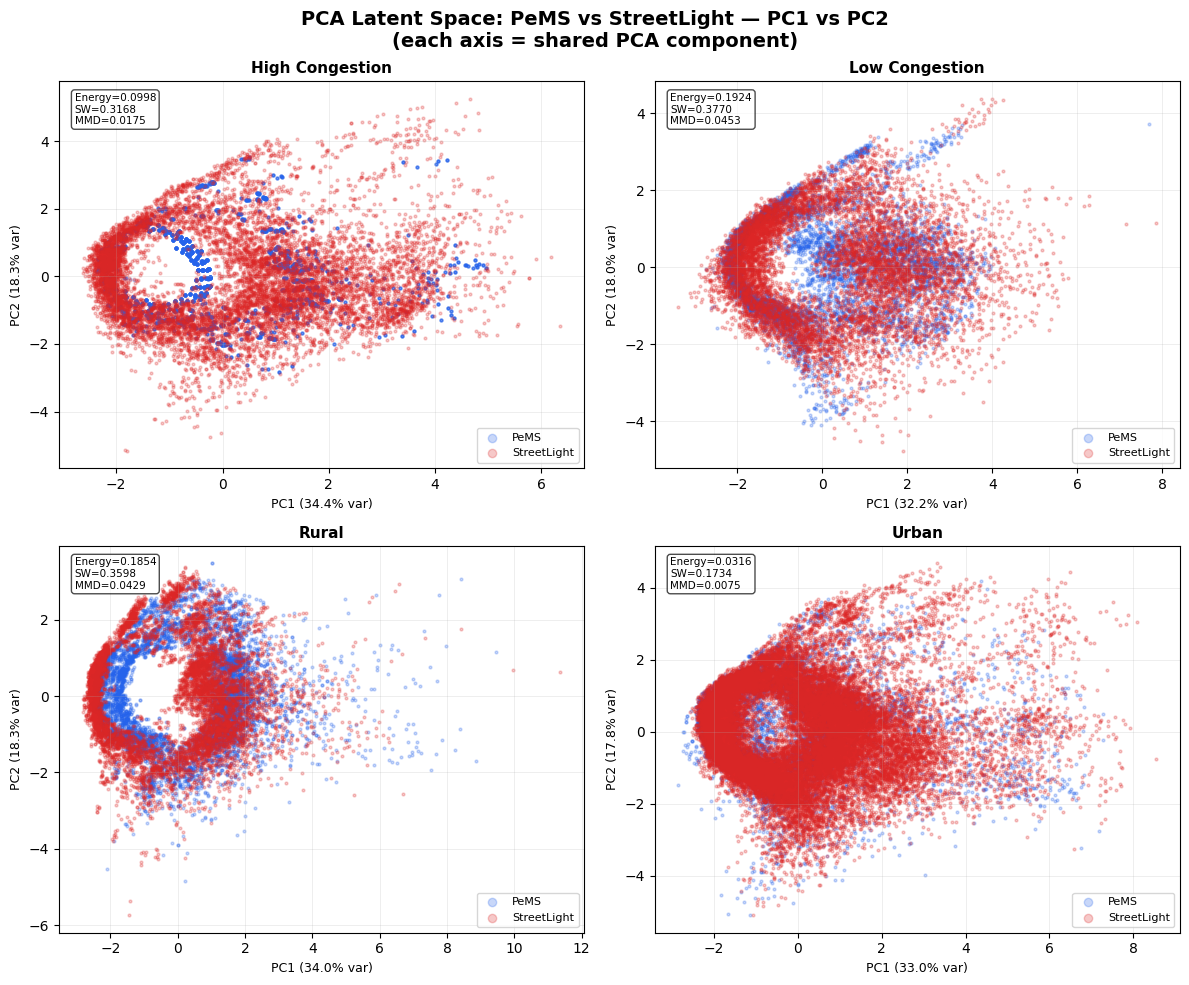

Saved: pca_pc1_vs_pc2_all_regions.png


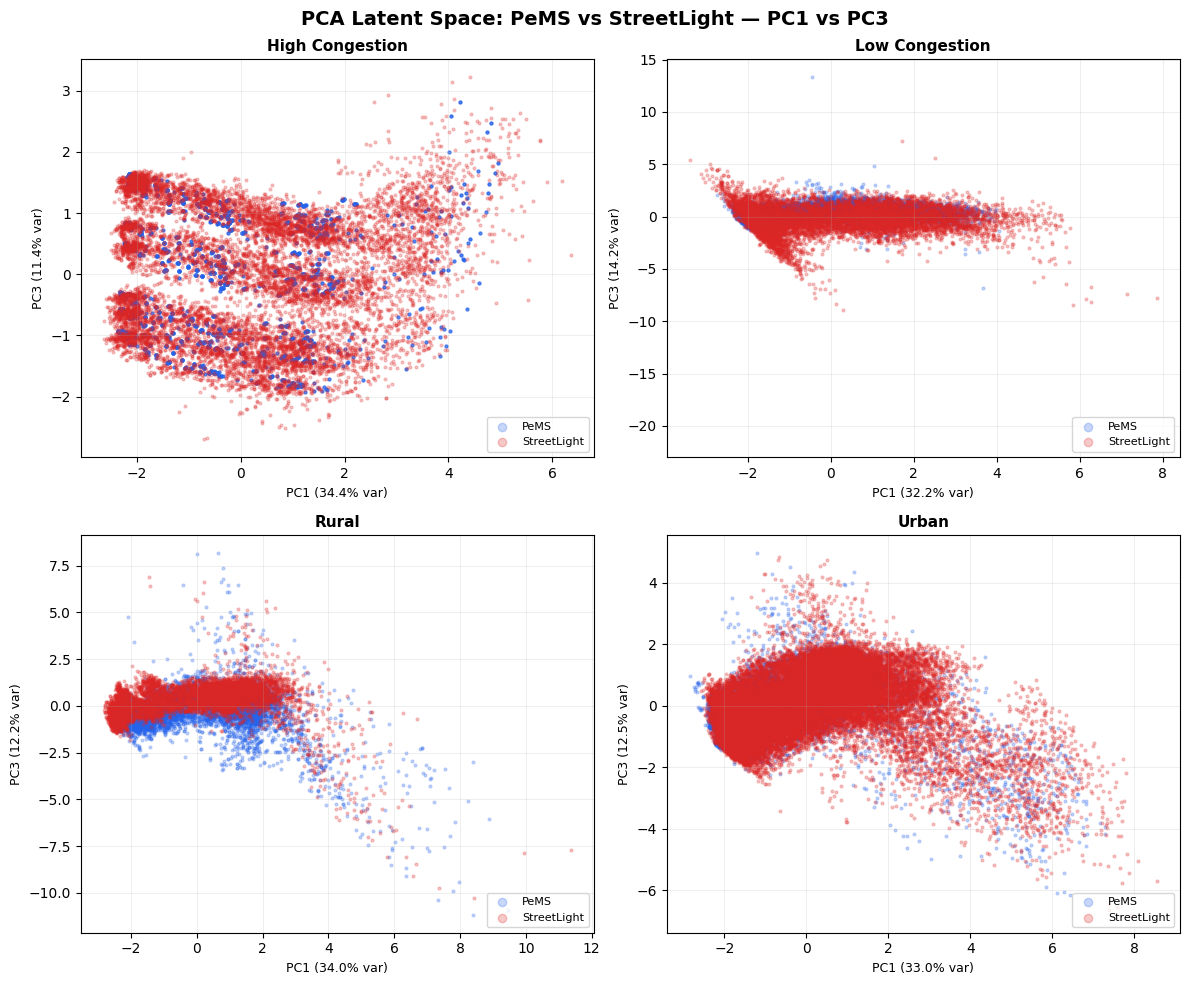

Saved: pca_pc1_vs_pc3_all_regions.png


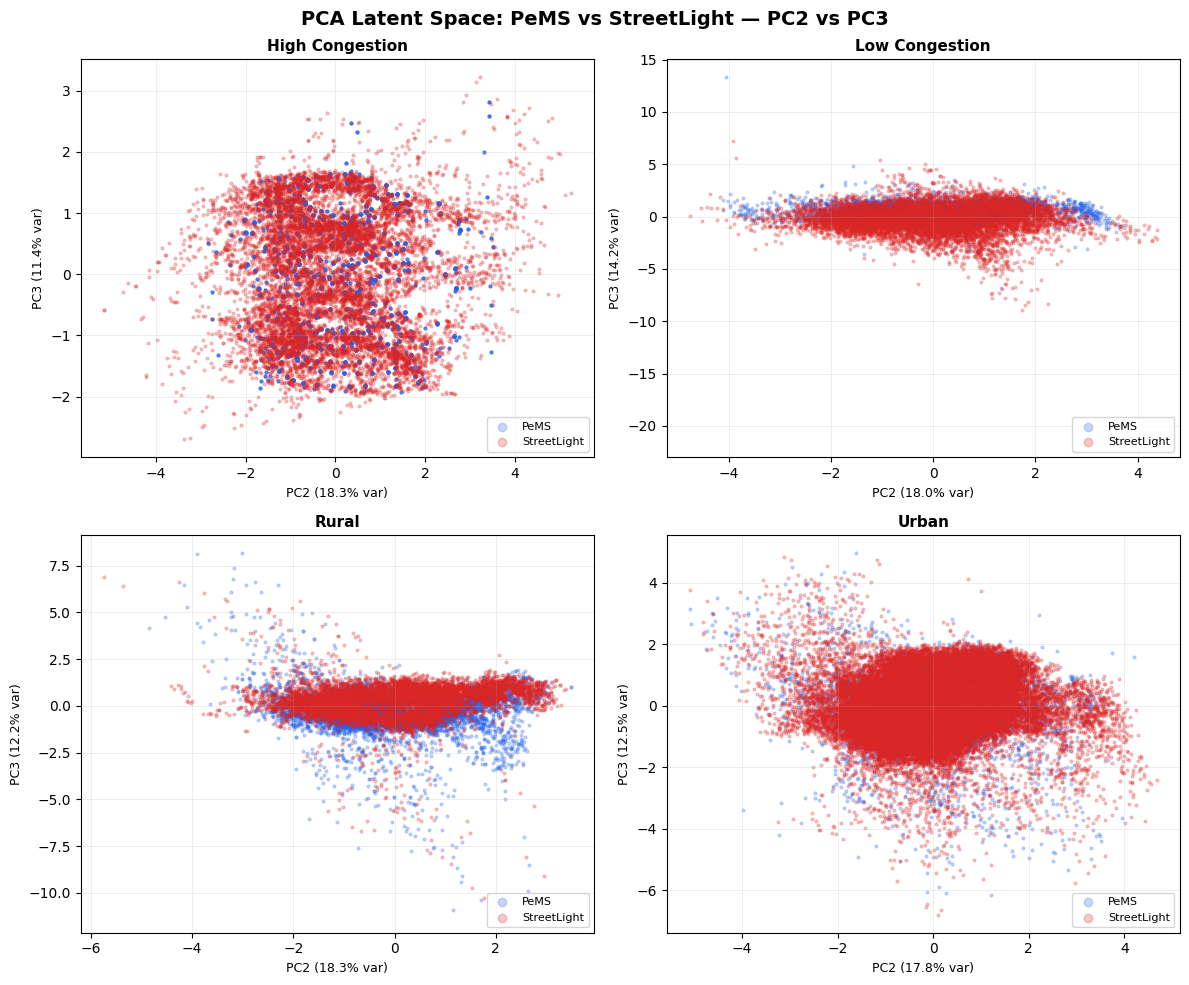

Saved: pca_pc2_vs_pc3_all_regions.png


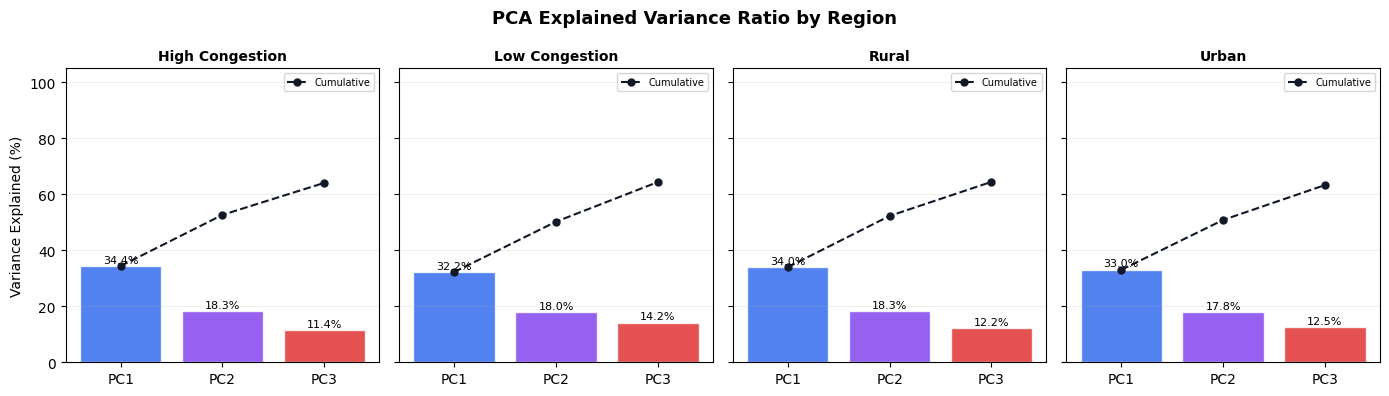

Saved: pca_explained_variance_all_regions.png


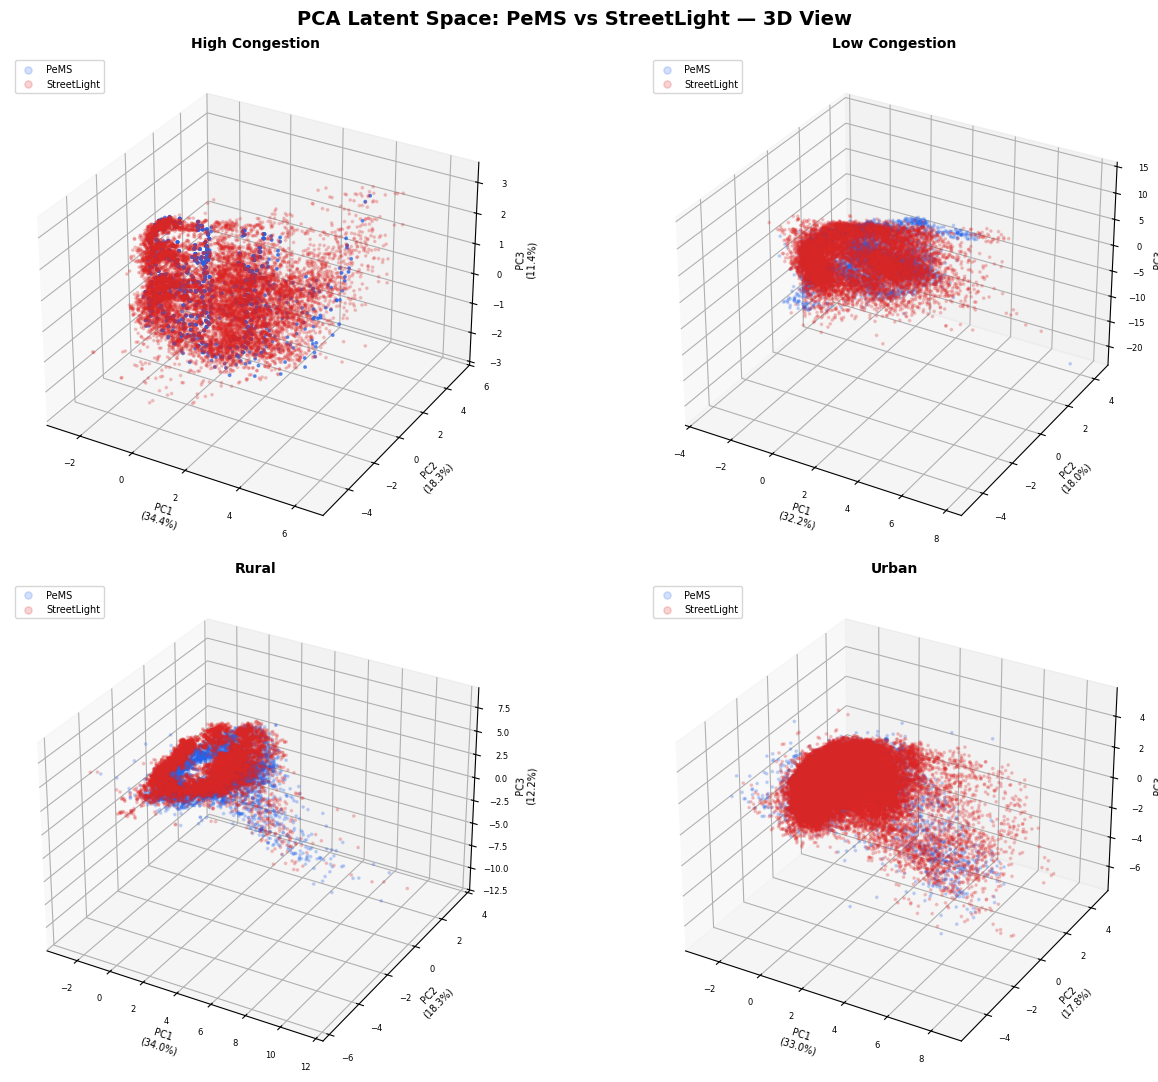

Saved: pca_3d_all_regions.png


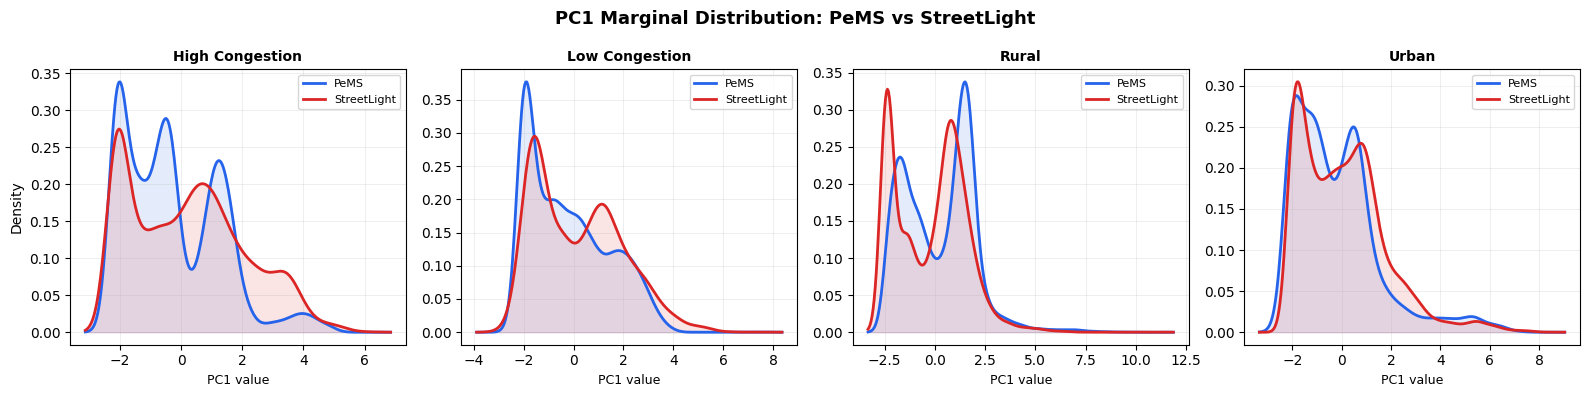

Saved: pca_kde_pc1_all_regions.png


In [ ]:
# PCA Scatter Plots for ALL Four Regions

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

regions = ["high", "low", "rural", "urban"]
region_labels = {"high": "High Congestion", "low": "Low Congestion",
                 "rural": "Rural", "urban": "Urban"}


fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("PCA Latent Space: PeMS vs StreetLight — PC1 vs PC2\n(each axis = shared PCA component)", fontsize=14, fontweight="bold")

for ax, r in zip(axes.flat, regions):
    X = region_mats_B[r]["X_latent"]
    Y = region_mats_B[r]["Y_latent"]
    ev = region_mats_B[r]["explained_var_ratio"]

    ax.scatter(X[:, 0], X[:, 1], s=4, alpha=0.25, color="#2563EB", label="PeMS", rasterized=True)
    ax.scatter(Y[:, 0], Y[:, 1], s=4, alpha=0.25, color="#DC2626", label="StreetLight", rasterized=True)

    # Annotate with metric values
    ed  = energy_results[r]
    sw  = sw_results[r]
    mmd = mmd_results[r]
    ax.text(0.03, 0.97,
            f"Energy={ed:.4f}\nSW={sw:.4f}\nMMD={mmd:.4f}",
            transform=ax.transAxes, fontsize=7.5, va="top",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))

    ax.set_title(f"{region_labels[r]}", fontsize=11, fontweight="bold")
    ax.set_xlabel(f"PC1 ({ev[0]*100:.1f}% var)", fontsize=9)
    ax.set_ylabel(f"PC2 ({ev[1]*100:.1f}% var)", fontsize=9)
    ax.legend(markerscale=3, fontsize=8, loc="lower right")
    ax.grid(alpha=0.3, linewidth=0.5)

plt.tight_layout()
plt.savefig("pca_pc1_vs_pc2_all_regions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: pca_pc1_vs_pc2_all_regions.png")



fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("PCA Latent Space: PeMS vs StreetLight — PC1 vs PC3", fontsize=14, fontweight="bold")

for ax, r in zip(axes.flat, regions):
    X = region_mats_B[r]["X_latent"]
    Y = region_mats_B[r]["Y_latent"]
    ev = region_mats_B[r]["explained_var_ratio"]

    ax.scatter(X[:, 0], X[:, 2], s=4, alpha=0.25, color="#2563EB", label="PeMS", rasterized=True)
    ax.scatter(Y[:, 0], Y[:, 2], s=4, alpha=0.25, color="#DC2626", label="StreetLight", rasterized=True)

    ax.set_title(f"{region_labels[r]}", fontsize=11, fontweight="bold")
    ax.set_xlabel(f"PC1 ({ev[0]*100:.1f}% var)", fontsize=9)
    ax.set_ylabel(f"PC3 ({ev[2]*100:.1f}% var)", fontsize=9)
    ax.legend(markerscale=3, fontsize=8, loc="lower right")
    ax.grid(alpha=0.3, linewidth=0.5)

plt.tight_layout()
plt.savefig("pca_pc1_vs_pc3_all_regions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: pca_pc1_vs_pc3_all_regions.png")



fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("PCA Latent Space: PeMS vs StreetLight — PC2 vs PC3", fontsize=14, fontweight="bold")

for ax, r in zip(axes.flat, regions):
    X = region_mats_B[r]["X_latent"]
    Y = region_mats_B[r]["Y_latent"]
    ev = region_mats_B[r]["explained_var_ratio"]

    ax.scatter(X[:, 1], X[:, 2], s=4, alpha=0.25, color="#2563EB", label="PeMS", rasterized=True)
    ax.scatter(Y[:, 1], Y[:, 2], s=4, alpha=0.25, color="#DC2626", label="StreetLight", rasterized=True)

    ax.set_title(f"{region_labels[r]}", fontsize=11, fontweight="bold")
    ax.set_xlabel(f"PC2 ({ev[1]*100:.1f}% var)", fontsize=9)
    ax.set_ylabel(f"PC3 ({ev[2]*100:.1f}% var)", fontsize=9)
    ax.legend(markerscale=3, fontsize=8, loc="lower right")
    ax.grid(alpha=0.3, linewidth=0.5)

plt.tight_layout()
plt.savefig("pca_pc2_vs_pc3_all_regions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: pca_pc2_vs_pc3_all_regions.png")


# Explained Variance Ratio per Region
fig, axes = plt.subplots(1, 4, figsize=(14, 4), sharey=True)
fig.suptitle("PCA Explained Variance Ratio by Region", fontsize=13, fontweight="bold")

for ax, r in zip(axes, regions):
    ev = region_mats_B[r]["explained_var_ratio"]
    cumev = np.cumsum(ev)
    pcs = [f"PC{i+1}" for i in range(len(ev))]

    bars = ax.bar(pcs, ev * 100, color=["#2563EB", "#7C3AED", "#DC2626"], alpha=0.8, edgecolor="white")
    ax.plot(pcs, cumev * 100, "o--", color="#111827", linewidth=1.5, markersize=5, label="Cumulative")

    for bar, val in zip(bars, ev):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f"{val*100:.1f}%", ha="center", va="bottom", fontsize=8)

    ax.set_title(region_labels[r], fontsize=10, fontweight="bold")
    ax.set_ylabel("Variance Explained (%)" if ax == axes[0] else "")
    ax.set_ylim(0, 105)
    ax.grid(axis="y", alpha=0.3, linewidth=0.5)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig("pca_explained_variance_all_regions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: pca_explained_variance_all_regions.png")


# 3D PCA scatter
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

fig = plt.figure(figsize=(14, 11))
fig.suptitle("PCA Latent Space: PeMS vs StreetLight — 3D View", fontsize=14, fontweight="bold")

for i, r in enumerate(regions):
    ax = fig.add_subplot(2, 2, i+1, projection="3d")
    X = region_mats_B[r]["X_latent"]
    Y = region_mats_B[r]["Y_latent"]
    ev = region_mats_B[r]["explained_var_ratio"]

    ax.scatter(X[:, 0], X[:, 1], X[:, 2], s=3, alpha=0.2, color="#2563EB", label="PeMS", rasterized=True)
    ax.scatter(Y[:, 0], Y[:, 1], Y[:, 2], s=3, alpha=0.2, color="#DC2626", label="StreetLight", rasterized=True)

    ax.set_title(region_labels[r], fontsize=10, fontweight="bold")
    ax.set_xlabel(f"PC1\n({ev[0]*100:.1f}%)", fontsize=7, labelpad=2)
    ax.set_ylabel(f"PC2\n({ev[1]*100:.1f}%)", fontsize=7, labelpad=2)
    ax.set_zlabel(f"PC3\n({ev[2]*100:.1f}%)", fontsize=7, labelpad=2)
    ax.legend(markerscale=3, fontsize=7, loc="upper left")
    ax.tick_params(labelsize=6)

plt.tight_layout()
plt.savefig("pca_3d_all_regions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: pca_3d_all_regions.png")


# Density (KDE) overlay per region — PC1 marginal
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("PC1 Marginal Distribution: PeMS vs StreetLight", fontsize=13, fontweight="bold")

for ax, r in zip(axes, regions):
    X = region_mats_B[r]["X_latent"][:, 0]
    Y = region_mats_B[r]["Y_latent"][:, 0]

    xgrid = np.linspace(min(X.min(), Y.min()) - 0.5, max(X.max(), Y.max()) + 0.5, 300)

    kde_x = gaussian_kde(X, bw_method="scott")
    kde_y = gaussian_kde(Y, bw_method="scott")

    ax.plot(xgrid, kde_x(xgrid), color="#2563EB", linewidth=2, label="PeMS")
    ax.plot(xgrid, kde_y(xgrid), color="#DC2626", linewidth=2, label="StreetLight")
    ax.fill_between(xgrid, kde_x(xgrid), alpha=0.12, color="#2563EB")
    ax.fill_between(xgrid, kde_y(xgrid), alpha=0.12, color="#DC2626")

    ax.set_title(region_labels[r], fontsize=10, fontweight="bold")
    ax.set_xlabel("PC1 value", fontsize=9)
    ax.set_ylabel("Density" if ax == axes[0] else "")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3, linewidth=0.5)

plt.tight_layout()
plt.savefig("pca_kde_pc1_all_regions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: pca_kde_pc1_all_regions.png")

In [ ]:
# Feature-group selection for similarity analysis

FEATURE_GROUPS = {
    "all": [
        "flow",
        "speed",
        "density_proxy",
        "flow_diff1",
        "speed_diff1",
        "hour_sin",
        "hour_cos",
        "dow_sin",
        "dow_cos",
    ],
    "flow": [
        "flow",
        "density_proxy",
        "flow_diff1",
    ],
    "speed": [
        "speed",
        "density_proxy",
        "speed_diff1",
    ],
    "temporal": [
        "hour_sin",
        "hour_cos",
        "dow_sin",
        "dow_cos",
    ],
    "dynamics": [
        "flow_diff1",
        "speed_diff1",
        "density_proxy",
    ],
    "flow_speed_only": [
        "flow",
        "speed",
    ],
}

In [ ]:
# Utility functions to rebuild feature spaces by selection

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import rbf_kernel
from scipy.spatial.distance import cdist
from scipy.stats import wasserstein_distance
import numpy as np
import pandas as pd

def build_region_feature_mats_from_cols(p_df, s_df, feat_cols):
    region_mats = {}

    for r in ["high", "low", "rural", "urban"]:
        P = p_df[p_df["region"] == r].copy().dropna(subset=feat_cols)
        S = s_df[s_df["region"] == r].copy().dropna(subset=feat_cols)

        X = P[feat_cols].to_numpy(float)
        Y = S[feat_cols].to_numpy(float)

        scaler = StandardScaler()
        Z = scaler.fit_transform(np.vstack([X, Y]))
        Xs = Z[:len(X)]
        Ys = Z[len(X):]

        region_mats[r] = {
            "X": Xs,
            "Y": Ys,
            "X_raw": X,
            "Y_raw": Y,
            "n_pems": len(X),
            "n_sl": len(Y),
            "scaler": scaler,
            "feat_cols": feat_cols,
        }

    return region_mats


def build_region_pca_latent_auto(region_mats, max_components=5, variance_threshold=0.90, seed=0):
    region_latent = {}

    for r, obj in region_mats.items():
        X = obj["X"]
        Y = obj["Y"]
        Z = np.vstack([X, Y])

        max_k = min(max_components, Z.shape[1], max(2, Z.shape[0] - 1))
        pca_full = PCA(n_components=max_k, random_state=seed)
        pca_full.fit(Z)

        cum_var = np.cumsum(pca_full.explained_variance_ratio_)
        chosen_k = int(np.argmax(cum_var >= variance_threshold) + 1)
        chosen_k = max(2, min(chosen_k, max_k)) if max_k >= 2 else 1

        pca = PCA(n_components=chosen_k, random_state=seed)
        Z_lat = pca.fit_transform(Z)

        X_lat = Z_lat[:len(X)]
        Y_lat = Z_lat[len(X):]

        region_latent[r] = {
            "X_latent": X_lat,
            "Y_latent": Y_lat,
            "pca": pca,
            "explained_var_ratio": pca.explained_variance_ratio_,
            "explained_var_sum": pca.explained_variance_ratio_.sum(),
            "n_components": chosen_k,
            "feat_cols": obj["feat_cols"],
            "n_pems": obj["n_pems"],
            "n_sl": obj["n_sl"],
        }

    return region_latent


def energy_distance(X, Y):
    XY = cdist(X, Y)
    XX = cdist(X, X)
    YY = cdist(Y, Y)
    return 2 * np.mean(XY) - np.mean(XX) - np.mean(YY)


def sliced_wasserstein(X, Y, n_proj=100, seed=0):
    rng = np.random.default_rng(seed)
    d = X.shape[1]
    vals = []

    for _ in range(n_proj):
        theta = rng.normal(size=d)
        theta /= np.linalg.norm(theta)
        vals.append(wasserstein_distance(X @ theta, Y @ theta))

    return np.mean(vals)


def compute_mmd(X, Y, gamma=None):
    if gamma is None:
        gamma = 1 / X.shape[1]
    Kxx = rbf_kernel(X, X, gamma)
    Kyy = rbf_kernel(Y, Y, gamma)
    Kxy = rbf_kernel(X, Y, gamma)
    return Kxx.mean() + Kyy.mean() - 2 * Kxy.mean()


def summarize_similarity_for_feature_group(p_feat, s_feat, feat_group_name, feat_cols):
    mats = build_region_feature_mats_from_cols(p_feat, s_feat, feat_cols)
    latent = build_region_pca_latent_auto(mats, max_components=5, variance_threshold=0.90)

    rows = []
    for region in ["high", "low", "rural", "urban"]:
        X = latent[region]["X_latent"]
        Y = latent[region]["Y_latent"]

        rows.append({
            "feature_group": feat_group_name,
            "region": region,
            "n_features": len(feat_cols),
            "selected_features": ", ".join(feat_cols),
            "latent_dim": latent[region]["n_components"],
            "explained_var_sum": latent[region]["explained_var_sum"],
            "energy": energy_distance(X, Y),
            "wasserstein": sliced_wasserstein(X, Y, n_proj=100, seed=0),
            "mmd": compute_mmd(X, Y),
        })

    return pd.DataFrame(rows), mats, latent

In [ ]:
# Run similarity analysis for all feature groups

all_similarity_results = []
feature_group_objects = {}

for group_name, feat_cols in FEATURE_GROUPS.items():
    df_group, mats_group, latent_group = summarize_similarity_for_feature_group(
        p_feat, s_feat, group_name, feat_cols
    )
    all_similarity_results.append(df_group)
    feature_group_objects[group_name] = {
        "mats": mats_group,
        "latent": latent_group,
        "features": feat_cols,
    }

similarity_results_all = pd.concat(all_similarity_results, ignore_index=True)

print(similarity_results_all.head(12))
similarity_results_all.to_csv(OUT_DIR / "similarity_results_by_feature_group.csv", index=False)

   feature_group region  n_features  \
0            all   high           9   
1            all    low           9   
2            all  rural           9   
3            all  urban           9   
4           flow   high           3   
5           flow    low           3   
6           flow  rural           3   
7           flow  urban           3   
8          speed   high           3   
9          speed    low           3   
10         speed  rural           3   
11         speed  urban           3   

                                    selected_features  latent_dim  \
0   flow, speed, density_proxy, flow_diff1, speed_...           2   
1   flow, speed, density_proxy, flow_diff1, speed_...           2   
2   flow, speed, density_proxy, flow_diff1, speed_...           2   
3   flow, speed, density_proxy, flow_diff1, speed_...           2   
4                     flow, density_proxy, flow_diff1           2   
5                     flow, density_proxy, flow_diff1           2   
6        

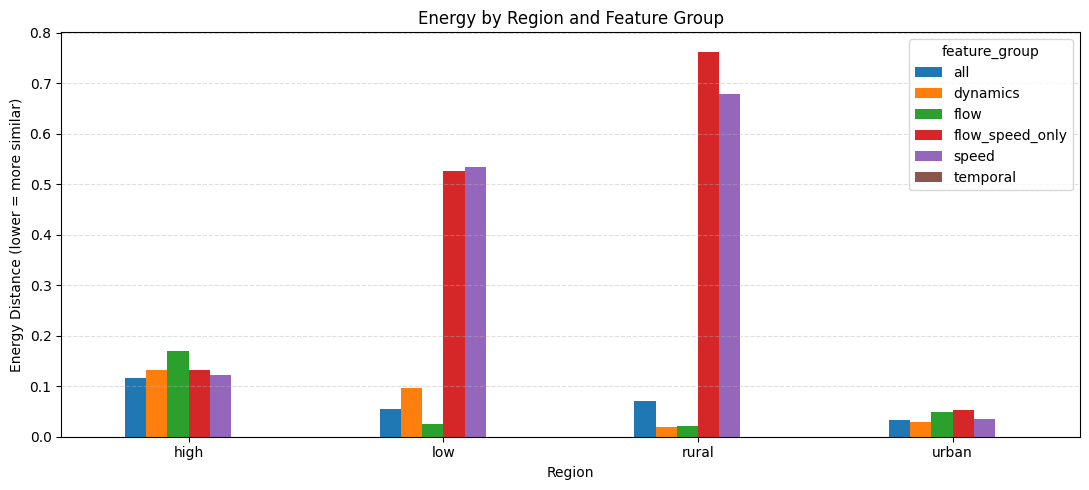

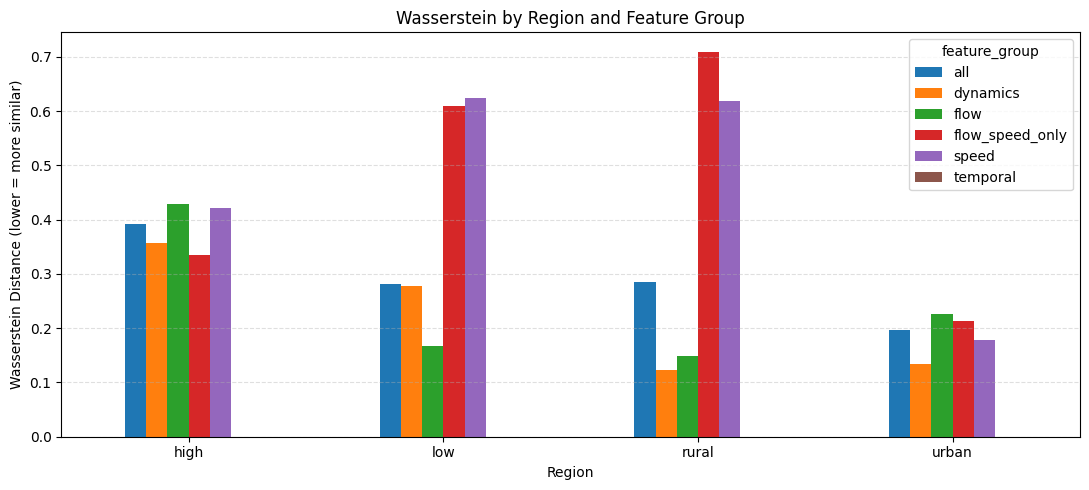

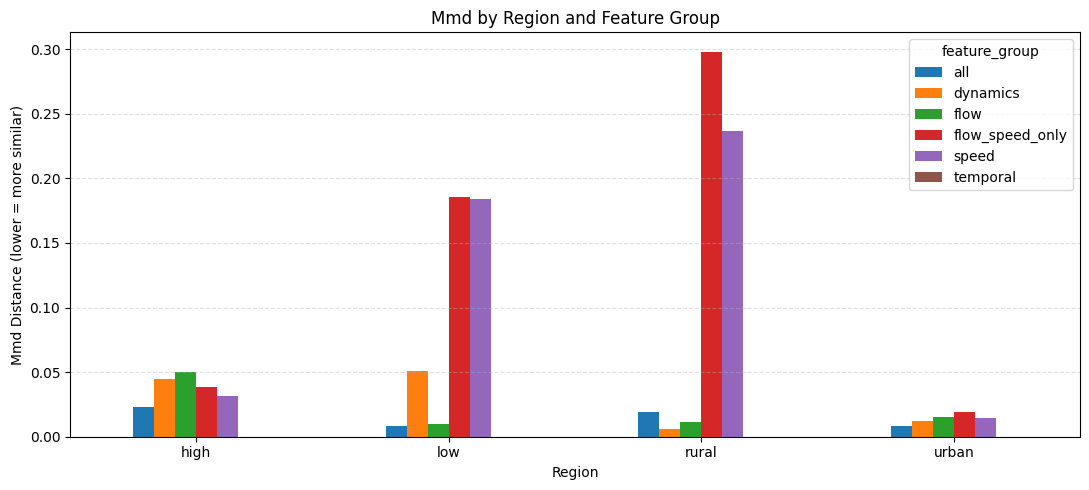

In [ ]:
# Compare feature groups side by side

import matplotlib.pyplot as plt

for metric in ["energy", "wasserstein", "mmd"]:
    pivot_df = similarity_results_all.pivot(index="region", columns="feature_group", values=metric)

    plt.figure(figsize=(11, 5))
    pivot_df.plot(kind="bar", ax=plt.gca())
    plt.title(f"{metric.capitalize()} by Region and Feature Group")
    plt.ylabel(f"{metric.capitalize()} Distance (lower = more similar)")
    plt.xlabel("Region")
    plt.xticks(rotation=0)
    plt.grid(axis="y", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"{metric}_feature_group_comparison.png", dpi=300, bbox_inches="tight")
    plt.show()

In [ ]:
!pip -q install plotly

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from pathlib import Path

dashboard_dir = Path("dashboard_assets")
dashboard_dir.mkdir(exist_ok=True)

In [ ]:
# Build a tidy dataframe for PCA points across all feature groups
pca_rows = []

for group_name, obj in feature_group_objects.items():
    latent_obj = obj["latent"]

    for region in ["high", "low", "rural", "urban"]:
        X = latent_obj[region]["X_latent"]
        Y = latent_obj[region]["Y_latent"]
        evr = latent_obj[region]["explained_var_ratio"]

        for i in range(len(X)):
            pca_rows.append({
                "feature_group": group_name,
                "region": region,
                "source": "PeMS",
                "PC1": X[i, 0] if X.shape[1] > 0 else 0,
                "PC2": X[i, 1] if X.shape[1] > 1 else 0,
                "evr1": evr[0] if len(evr) > 0 else np.nan,
                "evr2": evr[1] if len(evr) > 1 else np.nan,
            })

        for i in range(len(Y)):
            pca_rows.append({
                "feature_group": group_name,
                "region": region,
                "source": "StreetLight",
                "PC1": Y[i, 0] if Y.shape[1] > 0 else 0,
                "PC2": Y[i, 1] if Y.shape[1] > 1 else 0,
                "evr1": evr[0] if len(evr) > 0 else np.nan,
                "evr2": evr[1] if len(evr) > 1 else np.nan,
            })

pca_dashboard_df = pd.DataFrame(pca_rows)
pca_dashboard_df.to_csv(dashboard_dir / "pca_dashboard_points.csv", index=False)

In [ ]:
!pip -q install dash dash-bootstrap-components plotly pandas numpy scipy scikit-learn openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 31.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 9.3 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import rbf_kernel
from scipy.spatial.distance import cdist
from scipy.stats import wasserstein_distance


required_objs = ["pems_aligned", "sl_aligned"]
missing = [x for x in required_objs if x not in globals()]
if missing:
    raise ValueError(f"Missing required objects in memory: {missing}. Run the earlier notebook cells first.")

print("pems_aligned shape:", pems_aligned.shape)
print("sl_aligned shape:", sl_aligned.shape)
print("regions in PeMS:", sorted(pems_aligned['region'].unique()))
print("regions in StreetLight:", sorted(sl_aligned['region'].unique()))

pems_aligned shape: (30176, 6)
sl_aligned shape: (58880, 6)
regions in PeMS: ['high', 'low', 'rural', 'urban']
regions in StreetLight: ['high', 'low', 'rural', 'urban']


In [ ]:
def add_time_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["hour"] = out["timestamp"].dt.hour
    out["dow"] = out["timestamp"].dt.dayofweek
    out["hour_sin"] = np.sin(2 * np.pi * out["hour"] / 24)
    out["hour_cos"] = np.cos(2 * np.pi * out["hour"] / 24)
    out["dow_sin"] = np.sin(2 * np.pi * out["dow"] / 7)
    out["dow_cos"] = np.cos(2 * np.pi * out["dow"] / 7)
    return out

def add_density_proxy(df: pd.DataFrame, eps: float = 1e-6) -> pd.DataFrame:
    out = df.copy()
    out["density_proxy"] = out["flow"] / out["speed"].clip(lower=eps)
    return out

def add_station_dynamics(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy().sort_values(["region", "id", "timestamp"])
    g = out.groupby(["region", "id"], sort=False)
    out["flow_diff1"] = g["flow"].diff().fillna(0.0)
    out["speed_diff1"] = g["speed"].diff().fillna(0.0)
    return out

def add_time_slice(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    hour = out["timestamp"].dt.hour
    dow = out["timestamp"].dt.dayofweek

    out["day_type"] = np.where(dow < 5, "weekday", "weekend")

    conditions = [
        hour.between(6, 9),
        hour.between(10, 14),
        hour.between(15, 18),
    ]
    choices = ["am_peak", "midday", "pm_peak"]
    out["time_slice"] = np.select(conditions, choices, default="off_peak")
    return out

p_feat = add_time_slice(add_station_dynamics(add_density_proxy(add_time_features(pems_aligned))))
s_feat = add_time_slice(add_station_dynamics(add_density_proxy(add_time_features(sl_aligned))))

print("Feature-engineered PeMS:", p_feat.shape)
print("Feature-engineered StreetLight:", s_feat.shape)

Feature-engineered PeMS: (30176, 17)
Feature-engineered StreetLight: (58880, 17)


In [ ]:
merged = p_feat.merge(
    s_feat,
    on=["timestamp", "id", "region", "day_type", "time_slice"],
    how="inner",
    suffixes=("_pems", "_sl")
).copy()

print("Merged matched rows:", merged.shape)
print("Rows by region:")
print(merged.groupby("region").size())

Merged matched rows: (30176, 29)
Rows by region:
region
high     8096
low      6624
rural    7360
urban    8096
dtype: int64


In [ ]:
def energy_distance(X, Y):
    XY = cdist(X, Y)
    XX = cdist(X, X)
    YY = cdist(Y, Y)
    return float(2 * np.mean(XY) - np.mean(XX) - np.mean(YY))

def sliced_wasserstein(X, Y, n_proj=64, seed=0):
    rng = np.random.default_rng(seed)
    d = X.shape[1]
    vals = []
    for _ in range(n_proj):
        theta = rng.normal(size=d)
        theta /= np.linalg.norm(theta)
        vals.append(wasserstein_distance(X @ theta, Y @ theta))
    return float(np.mean(vals))

def compute_mmd(X, Y, gamma=None):
    if gamma is None:
        gamma = 1 / X.shape[1]
    Kxx = rbf_kernel(X, X, gamma=gamma)
    Kyy = rbf_kernel(Y, Y, gamma=gamma)
    Kxy = rbf_kernel(X, Y, gamma=gamma)
    return float(Kxx.mean() + Kyy.mean() - 2 * Kxy.mean())

In [ ]:
OUT_DIR = Path("useful_dashboard_data")
OUT_DIR.mkdir(exist_ok=True)

BASE_FEATURES = [
    "flow",
    "speed",
    "density_proxy",
    "flow_diff1",
    "speed_diff1",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
]

FEATURE_GROUPS = {
    "all": [
        "flow", "speed", "density_proxy",
        "flow_diff1", "speed_diff1",
        "hour_sin", "hour_cos", "dow_sin", "dow_cos"
    ],
    "flow": ["flow", "density_proxy", "flow_diff1"],
    "speed": ["speed", "density_proxy", "speed_diff1"],
    "temporal": ["hour_sin", "hour_cos", "dow_sin", "dow_cos"],
    "dynamics": ["flow_diff1", "speed_diff1", "density_proxy"],
}


# 1) summary_df
summary_rows = []

for feature_group_name, feat_cols in FEATURE_GROUPS.items():
    p_cols = [f"{c}_pems" for c in feat_cols]
    s_cols = [f"{c}_sl" for c in feat_cols]

    for (region, time_slice, day_type), g in merged.groupby(["region", "time_slice", "day_type"]):
        gp = g[p_cols].dropna()
        gs = g[s_cols].dropna()

        if len(gp) < 20 or len(gs) < 20:
            continue

        X = gp.to_numpy(float)
        Y = gs.to_numpy(float)

        scaler = StandardScaler()
        Z = scaler.fit_transform(np.vstack([X, Y]))
        Xs = Z[:len(X)]
        Ys = Z[len(X):]

        flow_abs = np.abs(g["flow_pems"] - g["flow_sl"])
        speed_abs = np.abs(g["speed_pems"] - g["speed_sl"])

        flow_den = g["flow_pems"].abs().sum()
        speed_den = g["speed_pems"].abs().sum()

        flow_error_pct = (flow_abs.sum() / flow_den * 100) if flow_den > 0 else np.nan
        speed_error_pct = (speed_abs.sum() / speed_den * 100) if speed_den > 0 else np.nan

        summary_rows.append({
             "region": region,
             "feature_group": feature_group_name,
             "time_slice": time_slice,
             "day_type": day_type,
             "n_pairs": len(g),
             "energy": energy_distance(Xs, Ys),
             "wasserstein": sliced_wasserstein(Xs, Ys),
             "mmd": compute_mmd(Xs, Ys),
             "flow_error_abs": float(flow_abs.mean()),
             "flow_error_pct": float(flow_error_pct),
             "speed_error_abs": float(speed_abs.mean()),
             "speed_error_pct": float(speed_error_pct),
             "mean_flow_pems": float(g["flow_pems"].mean()),
             "mean_flow_sl": float(g["flow_sl"].mean()),
             "mean_speed_pems": float(g["speed_pems"].mean()),
             "mean_speed_sl": float(g["speed_sl"].mean()),
       })

summary_df = pd.DataFrame(summary_rows)


# 2) hourly_df
hourly_df = (
    merged.assign(hour=merged["timestamp"].dt.hour)
    .groupby(["region", "day_type", "time_slice", "hour"], as_index=False)
    .agg(
        flow_pems=("flow_pems", "mean"),
        flow_sl=("flow_sl", "mean"),
        speed_pems=("speed_pems", "mean"),
        speed_sl=("speed_sl", "mean"),
    )
)

hourly_df["flow_abs_error"] = (hourly_df["flow_pems"] - hourly_df["flow_sl"]).abs()
hourly_df["speed_abs_error"] = (hourly_df["speed_pems"] - hourly_df["speed_sl"]).abs()
hourly_df["flow_pct_error"] = (
    hourly_df["flow_abs_error"] / hourly_df["flow_pems"].replace(0, np.nan)
) * 100
hourly_df["speed_pct_error"] = (
    hourly_df["speed_abs_error"] / hourly_df["speed_pems"].replace(0, np.nan)
) * 100

# 3) feature_df
feature_rows = []

for (region, day_type, time_slice), g in merged.groupby(["region", "day_type", "time_slice"]):
    for feat in BASE_FEATURES:
        pcol = f"{feat}_pems"
        scol = f"{feat}_sl"

        if pcol not in g.columns or scol not in g.columns:
            continue

        a = g[pcol].astype(float)
        b = g[scol].astype(float)

        valid = a.notna() & b.notna()
        a = a[valid]
        b = b[valid]

        if len(a) == 0:
            continue

        abs_err = (a - b).abs()

        # stable aggregated percentage error
        denom = a.abs().sum()
        agg_pct_err = (abs_err.sum() / denom * 100) if denom > 0 else np.nan

        feature_rows.append({
            "region": region,
            "day_type": day_type,
            "time_slice": time_slice,
            "feature": feat,
            "mae": float(abs_err.mean()),
            "mape_pct": float(agg_pct_err),
            "mean_pems": float(a.mean()),
            "mean_sl": float(b.mean()),
        })

feature_df = pd.DataFrame(feature_rows)


summary_df.to_csv(OUT_DIR / "summary_df.csv", index=False)
hourly_df.to_csv(OUT_DIR / "hourly_df.csv", index=False)
feature_df.to_csv(OUT_DIR / "feature_df.csv", index=False)

print("Saved dashboard prep files:")
print(OUT_DIR / "summary_df.csv")
print(OUT_DIR / "hourly_df.csv")
print(OUT_DIR / "feature_df.csv")

print("\nsummary_df:", summary_df.shape)
print("hourly_df:", hourly_df.shape)
print("feature_df:", feature_df.shape)

Saved dashboard prep files:
useful_dashboard_data/summary_df.csv
useful_dashboard_data/hourly_df.csv
useful_dashboard_data/feature_df.csv

summary_df: (160, 16)
hourly_df: (192, 12)
feature_df: (288, 8)


In [ ]:
print("\nSummary preview:")
display(summary_df.head())

print("\nHourly preview:")
display(hourly_df.head())

print("\nFeature preview:")
display(feature_df.head())

print("\nUnique regions in summary_df:", sorted(summary_df["region"].unique()))
print("Unique feature groups in summary_df:", sorted(summary_df["feature_group"].unique()))
print("Unique day types:", sorted(summary_df["day_type"].unique()))
print("Unique time slices:", sorted(summary_df["time_slice"].unique()))


Summary preview:


,region,feature_group,time_slice,day_type,n_pairs,energy,wasserstein,mmd,flow_error_abs,flow_error_pct,speed_error_abs,speed_error_pct,mean_flow_pems,mean_flow_sl,mean_speed_pems,mean_speed_sl
0,high,all,am_peak,weekday,1012,0.434226,0.400512,0.068846,1974.935771,45.129045,11.144664,19.061591,4376.196640,5967.373518,58.466601,52.164032
1,high,all,am_peak,weekend,352,0.192772,0.270389,0.030692,1158.843750,39.380836,2.775568,4.201211,2942.659091,3414.150568,66.065909,66.997159
2,high,all,midday,weekday,1265,0.425376,0.405944,0.065595,2458.018972,55.739790,7.230198,12.433693,4409.810277,6572.294071,58.150040,57.211067
3,high,all,midday,weekend,440,0.284412,0.331718,0.045304,1884.836364,41.211630,6.914091,11.464253,4573.554545,6076.463636,60.310000,59.954545
4,high,all,off_peak,weekday,2728,0.106313,0.199762,0.019258,1201.531891,56.256272,2.837793,4.221518,2135.818548,2705.659091,67.222104,66.153959



Hourly preview:


,region,day_type,time_slice,hour,flow_pems,flow_sl,speed_pems,speed_sl,flow_abs_error,speed_abs_error,flow_pct_error,speed_pct_error
0,high,weekday,am_peak,6,4313.509881,5103.656126,61.867194,55.806324,790.146245,6.060870,18.317942,9.796581
1,high,weekday,am_peak,7,4523.276680,6056.715415,58.154545,50.418972,1533.438735,7.735573,33.901060,13.301752
2,high,weekday,am_peak,8,4414.075099,6291.656126,56.534387,49.541502,1877.581028,6.992885,42.536228,12.369260
3,high,weekday,am_peak,9,4253.924901,6417.466403,57.310277,52.889328,2163.541502,4.420949,50.859889,7.714059
4,high,weekday,midday,10,4236.529644,6541.003953,57.873913,56.403162,2304.474308,1.470751,54.395331,2.541302



Feature preview:


,region,day_type,time_slice,feature,mae,mape_pct,mean_pems,mean_sl
0,high,weekday,am_peak,flow,1974.935771,45.129045,4376.196640,5967.373518
1,high,weekday,am_peak,speed,11.144664,19.061591,58.466601,52.164032
2,high,weekday,am_peak,density_proxy,64.921465,76.401415,84.974166,130.211078
3,high,weekday,am_peak,flow_diff1,819.294466,188.558147,231.212451,795.953557
4,high,weekday,am_peak,speed_diff1,5.649901,179.154003,-2.737055,-3.453557



Unique regions in summary_df: ['high', 'low', 'rural', 'urban']
Unique feature groups in summary_df: ['all', 'dynamics', 'flow', 'speed', 'temporal']
Unique day types: ['weekday', 'weekend']
Unique time slices: ['am_peak', 'midday', 'off_peak', 'pm_peak']


In [ ]:
default_check = summary_df[
    (summary_df["feature_group"] == "all") &
    (summary_df["day_type"] == "weekday") &
    (summary_df["time_slice"] == "am_peak")
].copy()

print(default_check[["region", "n_pairs", "energy", "flow_error_abs", "speed_error_abs"]])

   region  n_pairs    energy  flow_error_abs  speed_error_abs
0    high     1012  0.434226     1974.935771        11.144664
8     low      828  0.280447      679.669082         2.591546
16  rural      920  1.162545      486.553261        11.663804
24  urban     1012  0.077771     2331.261858        11.737352


In [ ]:
summary_df[["region", "time_slice", "day_type", "flow_error_abs", "flow_error_pct", "mean_flow_pems", "mean_flow_sl"]].sort_values("flow_error_pct", ascending=False).head(10)

,region,time_slice,day_type,flow_error_abs,flow_error_pct,mean_flow_pems,mean_flow_sl
28,urban,off_peak,weekday,913.618768,71.494565,1277.885630,1592.851173
156,urban,off_peak,weekday,913.618768,71.494565,1277.885630,1592.851173
92,urban,off_peak,weekday,913.618768,71.494565,1277.885630,1592.851173
60,urban,off_peak,weekday,913.618768,71.494565,1277.885630,1592.851173
124,urban,off_peak,weekday,913.618768,71.494565,1277.885630,1592.851173
24,urban,am_peak,weekday,2331.261858,66.101142,3526.810277,4205.744071
152,urban,am_peak,weekday,2331.261858,66.101142,3526.810277,4205.744071
120,urban,am_peak,weekday,2331.261858,66.101142,3526.810277,4205.744071
56,urban,am_peak,weekday,2331.261858,66.101142,3526.810277,4205.744071
88,urban,am_peak,weekday,2331.261858,66.101142,3526.810277,4205.744071
